<a href="https://colab.research.google.com/github/benasphy/Linear-Regression/blob/main/LinReg%20with%20RegressorMixin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0.5808173118722723


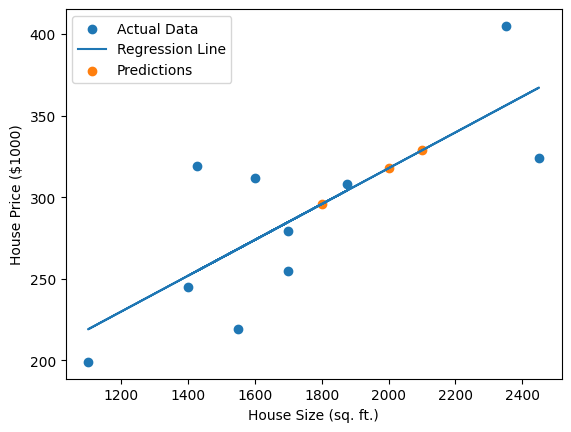

Predicted price for a 2000 sq. ft. house: $317.78
Predicted price for a 1800 sq. ft. house: $295.83
Predicted price for a 2100 sq. ft. house: $328.76


In [2]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
import matplotlib.pyplot as plt

# ---- Custom Linear Regression using RegressorMixin ----
class MyLinearRegressor(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        # Add bias term
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Normal Equation: theta = (X^T X)^(-1) X^T y
        self.theta_ = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        return self

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b @ self.theta_


# Example data
house_sizes = np.array([1400, 1600, 1700, 1875, 1100, 1550, 2350, 2450, 1425, 1700])
house_prices = np.array([245, 312, 279, 308, 199, 219, 405, 324, 319, 255])

# Reshape for model
X = house_sizes.reshape(-1, 1)
y = house_prices

# Use custom regressor
model = MyLinearRegressor()

# Train model
model.fit(X, y)

#Score
score = model.score(X, y)
print(score)
# Predict house prices for new sizes
new_sizes = np.array([2000, 1800, 2100]).reshape(-1, 1)
predictions = model.predict(new_sizes)

# Plot data and regression line
plt.scatter(house_sizes, house_prices, label='Actual Data')
plt.plot(house_sizes, model.predict(X), label='Regression Line')
plt.scatter(new_sizes, predictions, label='Predictions')
plt.xlabel('House Size (sq. ft.)')
plt.ylabel('House Price ($1000)')
plt.legend()
plt.show()

# Display predictions
for size, prediction in zip(new_sizes.flatten(), predictions):
    print(f"Predicted price for a {size} sq. ft. house: ${prediction:.2f}")
